In [37]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import mesmer
import model
import model_analysis

import importlib
import matplotlib.pyplot as plt
import xarray as xr

import numpy as np
from scipy.stats import skewnorm

import cartopy.crs as ccrs



In [38]:
is_local_data = True
Month_idx = 4
safe = False
start = None
end = None
max_depth = 3

### Load parameters of the transformations

In [39]:
mean_keys =["mean_1","mean_2"] 
var_keys = ["var_1","var_2"]

In [40]:
parameter_sets = {}
for mean_key in mean_keys:
    for var_key in var_keys:
        parameter_sets[f"{mean_key}_{var_key}"] = model.loading.load_params(var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/variations/mean_var_regr_degree/{mean_key}_{var_key}/local{is_local_data}/month{Month_idx}", name=f"start={start},end={end}.max_depth{max_depth}")    


the mask should only change if one is based on relative data, and one is abs because the threshold has a diffrent effect

In [41]:
for para_key,para in parameter_sets.items():
    print(parameter_sets["mean_1_var_1"]["detail_mask"].equals(para["detail_mask"]))

chunk_mask = parameter_sets["mean_1_var_1"]["chunk_mask"]


True
True
True
True


In [42]:
for para_key,para in parameter_sets.items():
    print(parameter_sets["mean_1_var_1"]["chunk_mask"].equals(para["chunk_mask"]))

detal_mask = parameter_sets["mean_1_var_1"]["detail_mask"]


True
True
True
True


In [43]:
for para_key,para in parameter_sets.items():
    print(parameter_sets["mean_1_var_1"]["local_maximas"].equals(para["local_maximas"]))

max = model.mask.mask_mask(parameter_sets["mean_1_var_1"]["local_maximas"],parameter_sets["mean_1_var_1"]["chunk_mask"].mrsol).isel(depth=slice(0, max_depth))
maximas = mesmer.grid.stack_lat_lon(max).drop_vars("depth_bnds").transpose("gridcell","depth").mrsol


True
True
True
True


### Load test input and target

In [44]:
run_idx = 4
raw_mrsol_for_test = model.loading.load_data_set(var = "mrsol", local = is_local_data, run_idx=run_idx)

tas_ds = model.loading.load_data_set(var = "tas", local = is_local_data, run_idx=run_idx)
pr_ds = model.loading.load_data_set(var = "pr", local = is_local_data, run_idx=run_idx)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=Month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=Month_idx)

raw_input_for_test = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")


### shape inputs

In [45]:
def shape_input(ds, chunk_mask):
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx)
    ds = model.mask.mask_mask(ds,chunk_mask)
    ds = mesmer.grid.stack_lat_lon(ds)
    return ds


In [46]:
input = shape_input(raw_input_for_test, chunk_mask.mrsol)

### shape targets

In [47]:
def shape_target(ds):
    #ds = ds.clip(min = 1e-32)
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx).isel(depth=slice(0, max_depth)).drop_vars("depth_bnds")
    return ds

In [48]:
def mask_stack_target(ds):
    masked_ds, chunk_mask, detail_mask= model.mask.mask_nonpositiv_height_chunks(ds)
    ds = mesmer.grid.stack_lat_lon(masked_ds)
    ds = ds.transpose("gridcell","time", "depth")
    return ds

In [49]:
target_unstacked = shape_target(raw_mrsol_for_test)
target = mask_stack_target(target_unstacked)

glaub unnötig
rel transform
maximas = parameter_sets["rel_transform"]["local_maximas"]
rel_target = raw_mrsol_for_test/maximas
rel_target = shape_target(rel_target)
targets["rel"] = mask_stack_target(rel_target)

Log transform
log_target = shape_target(raw_mrsol_for_test)
log_target = mask_stack_target(log_target)
targets["log"] = model.transform.Log_Transform_ds(log_target)
Logit transform
maximas = parameter_sets["logit_transform"]["local_maximas"]
logit_target = raw_mrsol_for_test/maximas
logit_target = shape_target(logit_target)
logit_target = mask_stack_target(logit_target)
targets["logit"] = model.transform.Logit_Transform_ds(logit_target)

### Emulate

In [50]:
predictions = {}

In [51]:
for mean_degree, mean_key in enumerate(mean_keys, start=1):
    for var_degree, var_key in enumerate(var_keys, start=1):
        #mean Prediction
        PolReg_mean = model.stats._parallel_polynomial_regression.ParPolyRegression(degree=mean_degree)
        PolReg_mean = PolReg_mean.from_params(parameter_sets[f"{mean_key}_{var_key}"]["mean"])
        predictions[f"{mean_key}_{var_key}"] = {}
        predictions[f"{mean_key}_{var_key}"]["mean"] = PolReg_mean.predict(input).transpose("gridcell","time", "depth")

        #var Prediction
        PolReg_var = model.stats._parallel_polynomial_regression.ParPolyRegression(degree=var_degree)
        PolReg_var = PolReg_var.from_params(parameter_sets[f"{mean_key}_{var_key}"]["variance"])
        predictions[f"{mean_key}_{var_key}"]["variance"] = PolReg_mean.predict(input).transpose("gridcell","time", "depth")

        

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 165, gridcell: 378)
Coordinates:
  * time     (time) datetime64[ns] 1kB 1850-04-30 1851-04-30 ... 2014-04-30
    lat      (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75 78.75
    lon      (gridcell) float64 3kB 288.0 288.0 288.0 ... 270.0 279.0 297.0
    height   float64 8B 2.0
Dimensions without coordinates: gridcell
Data variables:
    tas      (time, gridcell) float64 499kB 278.3 277.5 279.9 ... 249.3 251.1
    pr       (time, gridcell) float64 499kB 4.382e-05 4.235e-05 ... 6.366e-06
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:14:37 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...

#### Scores

In [52]:
score_sets = {}


In [53]:
score_keys = parameter_sets.keys()
score_keys

dict_keys(['mean_1_var_1', 'mean_1_var_2', 'mean_2_var_1', 'mean_2_var_2'])

In [54]:
predictions.keys()
predictions["mean_1_var_1"].keys()

dict_keys(['mean', 'variance'])

In [55]:
for key in score_keys:
    score_sets[key] = model_analysis.crps_score.crps_norm_score(predictions[key]["mean"],predictions[key]["variance"], target, transformation = "Logit", maximas_da = maximas,ensemble_size = 15)

In [56]:
for s_keys, scores in score_sets.items():
    score_sets[s_keys] = mesmer.grid.unstack_lat_lon_and_align(scores, target_unstacked)
    
    score_sets[s_keys] = model.mask.mask_mask(score_sets[s_keys],detal_mask.mrsol,"lon", "lat", "depth")
    

In [57]:
all_scores_ds =xr.Dataset({key : score.crps_score for key, score in score_sets.items()})

In [58]:
all_scores_ds.mean(dim=["lon","lat","time"])

<xarray.Dataset> Size: 120B
Dimensions:       (depth: 3)
Coordinates:
  * depth         (depth) float64 24B 0.03 0.19 0.78
Data variables:
    mean_1_var_1  (depth) float64 24B 0.8327 3.675 11.72
    mean_1_var_2  (depth) float64 24B 0.8332 3.676 11.78
    mean_2_var_1  (depth) float64 24B 0.8286 3.671 11.79
    mean_2_var_2  (depth) float64 24B 0.8288 3.675 11.78

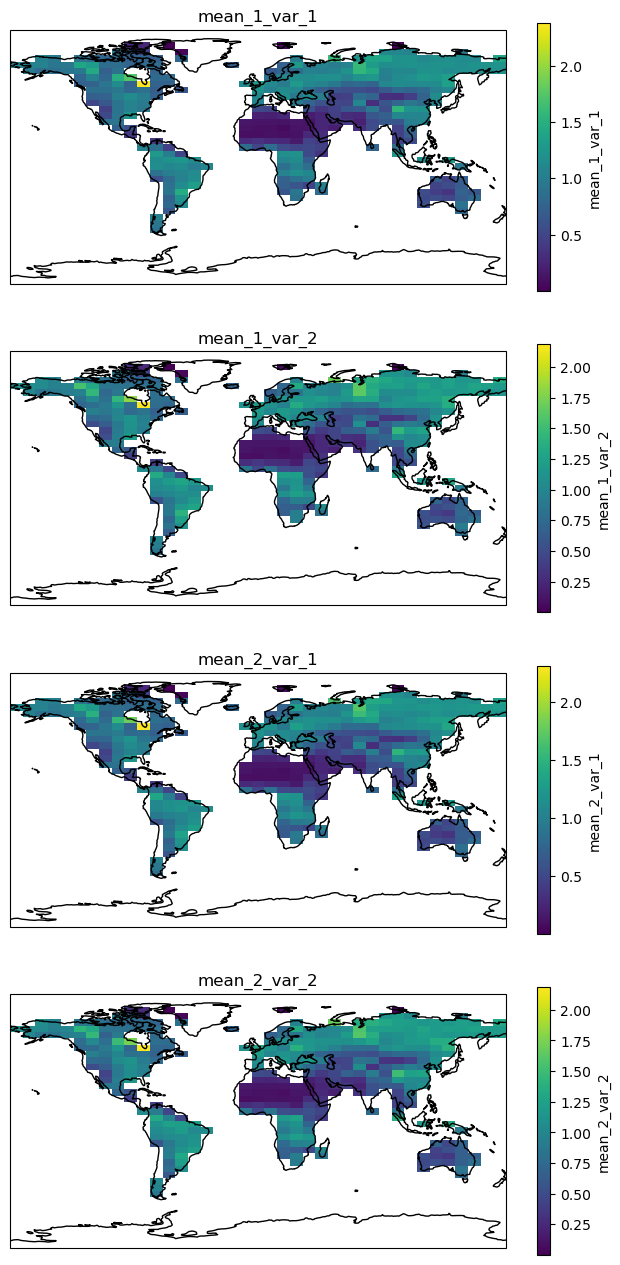

In [61]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=len(score_keys),
    ncols=1,
    figsize=(8, 4 * len(score_keys))
)
depth = 0

for i, s_key in enumerate(score_keys):
    da = all_scores_ds.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[i])
    ax[i].coastlines()
    ax[i].set_title(s_key)



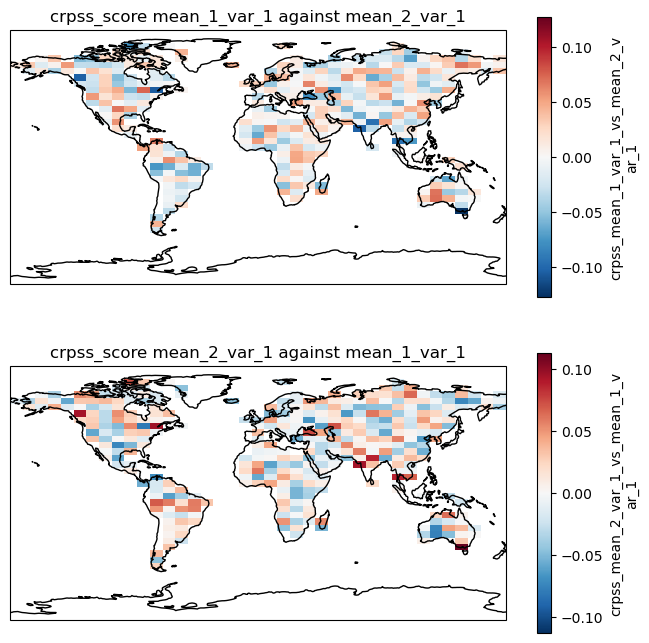

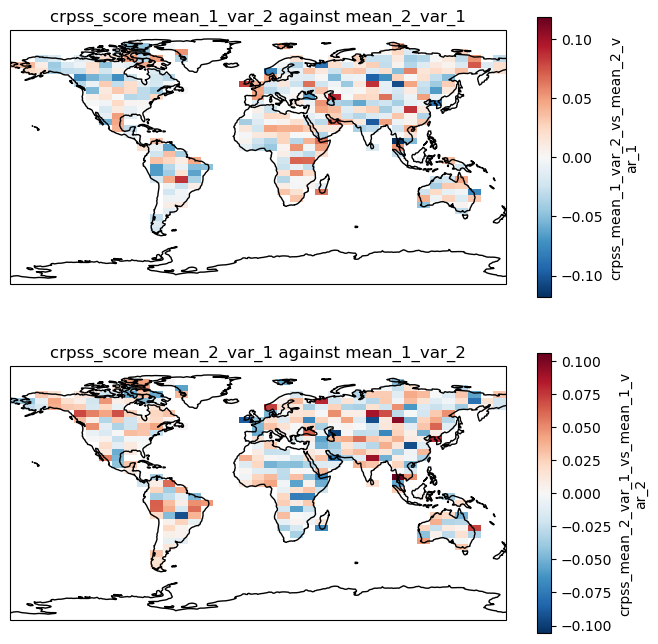

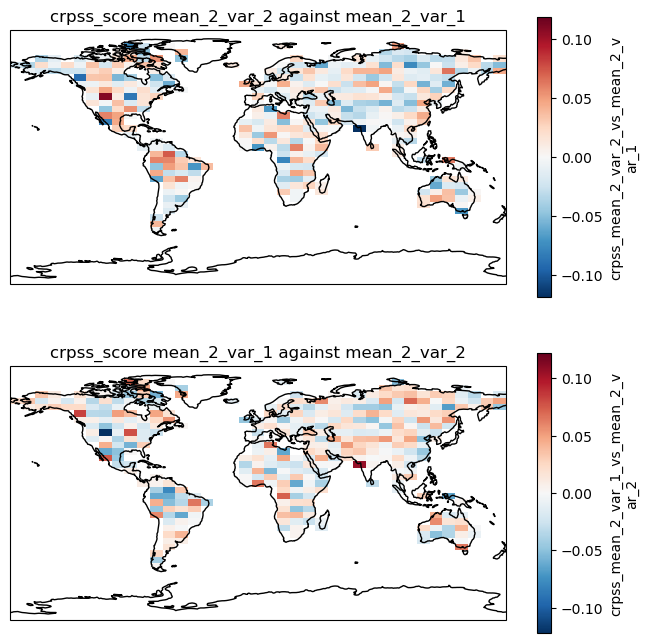

In [62]:
depth = 1

choice = "mean_2_var_1"

for i, s_key in enumerate(score_keys):
    if s_key == choice:
        continue
    vs = model_analysis.crps_score.combine_two_crps_and_the_crpss(score_sets[choice].crps_score,score_sets[s_key].crps_score,choice,s_key)

    fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=2,
    ncols=1,
    figsize=(8, 8)
    )
    """
    da = vs.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[0])
    ax[0].coastlines()
    ax[0].set_title(s_key)

    da = vs.isel(depth=depth).mean("time")[choice]
    da.plot(ax=ax[1])
    ax[1].coastlines()
    ax[1].set_title(choice)
    """
    da = vs.isel(depth=depth)[f"crpss_{s_key}_vs_{choice}"].clip(min=-1)
    da.plot(ax=ax[0])
    ax[0].coastlines()
    ax[0].set_title(f"crpss_score {s_key} against {choice}")

    da = vs.isel(depth=depth)[f"crpss_{choice}_vs_{s_key}"].clip(min=-1)
    da.plot(ax=ax[1])
    ax[1].coastlines()
    ax[1].set_title(f"crpss_score {choice} against {s_key}")

    fig_global_crpss.show()
    
